In [43]:
import pandas as pd
import numpy as np
np.random.seed(0) 

## I Datenprofiling

*Hier wird unser Datensatz systematisch analysiert, mit dem Ziel auf folgende Fragen zu antworten:*

Struktur: 
- Welche Spalten gibt es und welche Datentypen (Zahlen, Text, Datum) liegen vor?  
Vollständigkeit: 
- Gibt es fehlende Werte?  
Eindeutigkeit:
- Gibt es doppelte Einträge?  
Verteilung & Spannen: 
- Was ist der Mindest-, Höchst- und Durchschnittswert? 
- Gibt es bereits hier extreme Ausreißer?

In [44]:
luxury_datensatz = pd.read_csv("data/luxury_cosmetics_fraud_analysis_2025.csv")

luxury_datensatz.head() # Es fällt schon auf, dass ein Wert im Spalte Customer_Age in der 4. Zeile fehlt.

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count
0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56.0,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333
1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46.0,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406
2,29ad1278-70ce-421f-8d81-23816b39f4ac,dfa3d24d-b935-49a5-aa1d-7d57a44d8773,2025-02-20,12:36:02,32.0,Silver,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,79.207.35.55,0,96
3,07dc4894-e0eb-48f1-99a7-1942b1973d9b,7a67e184-9369-49ee-aeac-18f5b51b230f,2025-04-25,19:09:43,60.0,Bronze,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,176.194.167.253,0,186
4,ae407054-5543-429c-918a-cdcc42ea9782,cf14730a-8f5a-453d-b527-39a278852b27,2025-04-17,14:23:23,NaN,Platinum,Miami,BOUTIQUE-NYC,LUNAR-MASC-02,Serum,205.86,Gift Card,Mobile,166.31.46.111,0,179


In [45]:
# Jetzt kugen wir welches Teil diese fehlende Werde für jeden Spalte darstellen.
missing_value_count = luxury_datensatz.isnull().sum()

print(f"Fehlende Werte für jede Spalte \n {missing_value_count}")

#Wie viel Prozent ist das?
total_cells = np.prod(luxury_datensatz.shape)
total_missing = missing_value_count.sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print("-----------------------------------------------------------------------------------------")
print(f"{percent_missing} Prozent des Datensatzes ist fehlend")

Fehlende Werte für jede Spalte 
 Transaction_ID             0
Customer_ID                0
Transaction_Date           0
Transaction_Time           0
Customer_Age             106
Customer_Loyalty_Tier    106
Location                   0
Store_ID                   0
Product_SKU                0
Product_Category           0
Purchase_Amount            0
Payment_Method           106
Device_Type                0
IP_Address                 0
Fraud_Flag                 0
Footfall_Count             0
dtype: int64
-----------------------------------------------------------------------------------------
0.9317862165963432 Prozent des Datensatzes ist fehlend


### Struktur

Wir schauen uns die Datentypen jeder Spalte an, um zu prüfen, ob sie mit dem erwarteten Typ übereinstimmen (zum Beispiel ob `Transaction_Date` wirklich als Datum erkannt wird oder nur als Text/object vorliegt).

In [46]:
luxury_datensatz.info()

<class 'pandas.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         2133 non-null   str    
 1   Customer_ID            2133 non-null   str    
 2   Transaction_Date       2133 non-null   str    
 3   Transaction_Time       2133 non-null   str    
 4   Customer_Age           2027 non-null   float64
 5   Customer_Loyalty_Tier  2027 non-null   str    
 6   Location               2133 non-null   str    
 7   Store_ID               2133 non-null   str    
 8   Product_SKU            2133 non-null   str    
 9   Product_Category       2133 non-null   str    
 10  Purchase_Amount        2133 non-null   float64
 11  Payment_Method         2027 non-null   str    
 12  Device_Type            2133 non-null   str    
 13  IP_Address             2133 non-null   str    
 14  Fraud_Flag             2133 non-null   int64  
 15  Footfall_Count 

### Eindeutigkeit

Jede Transaktion sollte einen eindeutigen Eintrag darstellen. Wir prüfen deshalb, ob es komplett doppelte Zeilen gibt und ob die Transaction_ID mehrfach vorkommt.

In [47]:
anzahl_duplikate = luxury_datensatz.duplicated().sum()
anzahl_duplikate_id = luxury_datensatz["Transaction_ID"].duplicated().sum()

print(f"Anzahl komplett doppelter Zeilen: {anzahl_duplikate}")
print(f"Anzahl doppelter Transaction_ID: {anzahl_duplikate_id}")

Anzahl komplett doppelter Zeilen: 0
Anzahl doppelter Transaction_ID: 0


### Verteilung & Spannen

Mit describe() betrachten wir Minimum, Maximum, Mittelwert und Quartile der numerischen Spalten, um ein Gefühl für die Wertebereiche zu bekommen.

In [48]:
luxury_datensatz.describe()

,Customer_Age,Purchase_Amount,Fraud_Flag,Footfall_Count
count,2027.000000,2133.000000,2133.000000,2133.000000
mean,41.684262,174.614074,0.030942,272.461791
std,13.718110,72.249043,0.173202,131.113027
min,18.000000,50.260000,0.000000,50.000000
25%,30.000000,113.850000,0.000000,157.000000
50%,42.000000,174.180000,0.000000,269.000000
75%,53.000000,236.360000,0.000000,388.000000
max,65.000000,299.910000,1.000000,500.000000


In [49]:
def iqr_ausreisser(spalte):
    q1 = luxury_datensatz[spalte].quantile(0.25)
    q3 = luxury_datensatz[spalte].quantile(0.75)
    iqr = q3 - q1
    untere_grenze = q1 - 1.5 * iqr
    obere_grenze = q3 + 1.5 * iqr
    ausreisser = luxury_datensatz[(luxury_datensatz[spalte] < untere_grenze) | (luxury_datensatz[spalte] > obere_grenze)]
    print(f"{spalte}: {len(ausreisser)} Ausreißer (Grenzen: {untere_grenze:.2f} bis {obere_grenze:.2f})")

for spalte in ["Purchase_Amount", "Customer_Age", "Footfall_Count"]:
    iqr_ausreisser(spalte)

Purchase_Amount: 0 Ausreißer (Grenzen: -69.92 bis 420.13)
Customer_Age: 0 Ausreißer (Grenzen: -4.50 bis 87.50)
Footfall_Count: 0 Ausreißer (Grenzen: -189.50 bis 734.50)


### Uneinheitliche Einträge

Wir prüfen die kategorischen Spalten auf uneinheitliche Schreibweisen, die eigentlich dieselbe Kategorie meinen würden. Dazu vergleichen wir die Anzahl eindeutiger Werte vor und nach dem Trimmen/Kleinschreiben je Spalte.

In [50]:
kategorische_spalten = ["Customer_Loyalty_Tier", "Location", "Product_Category", "Payment_Method", "Device_Type"]

for spalte in kategorische_spalten:
    vorher = luxury_datensatz[spalte].nunique()
    nachher = luxury_datensatz[spalte].str.strip().str.lower().nunique()
    print(f"{spalte}: {vorher} eindeutige Werte vorher, {nachher} nach Trimmen/Kleinschreiben")

Customer_Loyalty_Tier: 5 eindeutige Werte vorher, 5 nach Trimmen/Kleinschreiben
Location: 20 eindeutige Werte vorher, 20 nach Trimmen/Kleinschreiben
Product_Category: 10 eindeutige Werte vorher, 10 nach Trimmen/Kleinschreiben
Payment_Method: 4 eindeutige Werte vorher, 4 nach Trimmen/Kleinschreiben
Device_Type: 4 eindeutige Werte vorher, 4 nach Trimmen/Kleinschreiben




### Zusammenfassung Datenprofiling

- **Struktur:** 16 Spalten.
- **Vollständigkeit:** `Customer_Age`, `Customer_Loyalty_Tier` und `Payment_Method` haben je 106 fehlende Werte: 0.93% des Datensatzes
- **Eindeutigkeit:** Keine doppelten Zeilen und keine doppelten `Transaction_ID`.
- **Verteilung & Spannen:** Alle numerischen Spalten liegen in plausiblen Wertebereichen. Laut IQR-Methode gibt es keine extremen Ausreißer.
- **Uneinheitliche Einträge:** In den kategorischen Spalten wurden keine inkonsistenten Schreibweisen gefunden.

## II Quality-Checks

Jetzt implementieren wir vier Testen, die die Qualität eines Datensatzes überprüfen und für jeden Test gibt aus, ob der Datensatz der Test bestanden oder durchgefallen hat.

In [51]:
# Hier sammeln wir die Ergebnisse aller Checks, um am Ende einen Gesamtbericht zu erstellen.
qualitaets_ergebnisse = []

def pruefung_protokollieren(name, anzahl_verstoesse):
    bestanden = anzahl_verstoesse == 0
    qualitaets_ergebnisse.append({"Check": name, "Verstoesse": int(anzahl_verstoesse), "Bestanden": bestanden})
    status = "bestanden" if bestanden else "NICHT bestanden"
    print(f"[{status}] {name}: {anzahl_verstoesse} Verstoß/Verstöße")

### 1. Vollständigkeits-Check

Prüft, ob im Rohdatensatz fehlende Werte vorhanden sind. Aus dem Profiling (Abschnitt I) erwarten wir hier einen echten Verstoß: je 106 fehlende Werte in drei Spalten, also 318 insgesamt.

In [52]:
def check_vollstaendigkeit(df):
    anzahl_verstoesse = df.isnull().sum().sum()
    pruefung_protokollieren("Vollständigkeit ", anzahl_verstoesse)

check_vollstaendigkeit(luxury_datensatz)

[NICHT bestanden] Vollständigkeit : 318 Verstoß/Verstöße


### 2. Eindeutigkeits-Check

Prüft erneut auf komplett doppelte Zeilen und doppelte `Transaction_ID` — als eigenständige Funktion, damit dieselbe Regel automatisiert auf neu eintreffende Daten angewendet werden kann.

In [53]:
def check_eindeutigkeit(df):
    anzahl_verstoesse = df.duplicated().sum() + df["Transaction_ID"].duplicated().sum()
    pruefung_protokollieren("Eindeutigkeit ", anzahl_verstoesse)

check_eindeutigkeit(luxury_datensatz)

[bestanden] Eindeutigkeit : 0 Verstoß/Verstöße


### 3. Datums-Check

Prüft, ob `Transaction_Date` innerhalb eines plausiblen Zeitraums liegt. Die Spalte liegt weiterhin als Text im einheitlichen Format `YYYY-MM-DD` vor (siehe Abschnitt I) — der lexikographische Stringvergleich mit `between()` funktioniert dafür genauso korrekt wie ein Vergleich auf echten Datumswerten. Da der gesamte Datensatz aus dem Kalenderjahr 2025 stammt, verwenden wir diesen als erwarteten Zeitraum.

In [54]:
def check_datum(df, start="2025-01-01", ende="2025-12-31"):
    fehlende_daten = df["Transaction_Date"].isnull().sum()
    ausserhalb_zeitraum = (~df["Transaction_Date"].between(start, ende)).sum()
    anzahl_verstoesse = fehlende_daten + ausserhalb_zeitraum
    pruefung_protokollieren("Datum gültig und im erwarteten Zeitraum (2025)", anzahl_verstoesse)

check_datum(luxury_datensatz)

[bestanden] Datum gültig und im erwarteten Zeitraum (2025): 0 Verstoß/Verstöße


### 4. Wertebereichs-Check

Prüft, ob `Purchase_Amount`, `Customer_Age` und `Footfall_Count` in plausiblen Grenzen liegen: Kaufbeträge müssen positiv sein, das Kundenalter zwischen 18 und 100 Jahren liegen, und die Kundenfrequenz darf nicht negativ sein. Ein fehlender Wert erfüllt `between()` nicht, daher zählen die 106 fehlenden `Customer_Age`-Einträge hier zusätzlich zum Vollständigkeits-Check als eigenständiger Verstoß gegen den plausiblen Wertebereich.

In [55]:
def check_wertebereich(df):
    ungueltiger_betrag = (df["Purchase_Amount"] <= 0).sum()
    unplausibles_alter = (~df["Customer_Age"].between(18, 100)).sum()
    negative_frequenz = (df["Footfall_Count"] < 0).sum()
    anzahl_verstoesse = ungueltiger_betrag + unplausibles_alter + negative_frequenz
    pruefung_protokollieren("Wertebereiche plausibel ", anzahl_verstoesse)

check_wertebereich(luxury_datensatz)

[NICHT bestanden] Wertebereiche plausibel : 106 Verstoß/Verstöße


### Gesamtbericht

Alle vier Checks werden zu einem Gesamtbericht zusammengefasst, der auf einen Blick zeigt, welche Regeln erfüllt sind und welche Regel bei künftigen Datenlieferungen genauer geprüft werden müsste.

In [56]:
bericht = pd.DataFrame(qualitaets_ergebnisse)
bericht

,Check,Verstoesse,Bestanden
0,Vollständigkeit,318,False
1,Eindeutigkeit,0,True
2,Datum gültig und im erwarteten Zeitraum (2025),0,True
3,Wertebereiche plausibel,106,False


### Zusammenfassung Quality-Checks

Da die Checks decken zwei der vier Checks reale Verstöße auf:

1. **Vollständigkeit — NICHT bestanden (318 Verstöße)**
2. **Eindeutigkeit — bestanden (0 Verstöße)**
3. **Datum — bestanden (0 Verstöße)**
4. **Wertebereiche — NICHT bestanden (106 Verstöße):** Ausschließlich verursacht durch die fehlenden `Customer_Age`-Werte, die nicht erfüllen.


## III Isolation Forest

Die Quality-Checks aus Abschnitt II haben absichtlich reale Probleme im unbereinigten Datensatz aufgedeckt statt sie zu verschleiern. Für den `IsolationForest` aus scikit-learn brauchen wir dennoch numerischen Input ohne fehlende Werte — das lösen wir in diesem Abschnitt lokal, nur innerhalb der Merkmalsmatrix, ohne `luxury_datensatz` selbst zu verändern. Anders als bei den Quality-Checks kennt das Modell dabei `Fraud_Flag` nicht — es lernt ausschließlich aus den übrigen Merkmalen, welche Transaktionen strukturell ungewöhnlich sind. `Fraud_Flag` verwenden wir erst im Anschluss, um die gefundenen Anomalien zu validieren.

### Merkmalsauswahl (Feature Engineering)

Die aus Abschnitt II bekannten fehlenden Werte sind weiterhin vorhanden und müssen für das Modell behandelt werden, ohne den Ursprungsdatensatz zu verändern:
- `Customer_Age` (numerisch) wird nur innerhalb der Merkmalsmatrix mit dem Median gefüllt, da `IsolationForest` keine `NaN`-Werte verarbeiten kann.
- `Customer_Loyalty_Tier` und `Payment_Method` (kategorisch) benötigen keine separate Behandlung: `pd.get_dummies()` kodiert fehlende Werte automatisch als 0 in allen zugehörigen Dummy-Spalten, ohne dass dabei `NaN` in `X` entsteht.

In [57]:
luxury_datensatz["Transaction_Stunde"] = pd.to_datetime(luxury_datensatz["Transaction_Time"], format="%H:%M:%S").dt.hour

numerische_merkmale = ["Customer_Age", "Purchase_Amount", "Footfall_Count", "Transaction_Stunde"]
kategorische_merkmale = ["Customer_Loyalty_Tier", "Product_Category", "Payment_Method", "Device_Type", "Location"]

merkmale = luxury_datensatz[numerische_merkmale + kategorische_merkmale].copy()
merkmale["Customer_Age"] = merkmale["Customer_Age"].fillna(merkmale["Customer_Age"].median())

X = pd.get_dummies(merkmale, columns=kategorische_merkmale)
print(f"Merkmalsmatrix: {X.shape[0]} Zeilen, {X.shape[1]} Spalten (nach One-Hot-Encoding)")

Merkmalsmatrix: 2133 Zeilen, 47 Spalten (nach One-Hot-Encoding)


### Modelltraining

Wir trainieren den `IsolationForest` mit 200 Bäumen auf der Merkmalsmatrix `X`. Den `contamination`-Parameter (erwarteter Anteil an Anomalien) setzen wir auf die tatsächliche Fraud-Rate im Datensatz (~3,09 %), da uns `Fraud_Flag` für die Validierung vorliegt. 

In [59]:
from sklearn.ensemble import IsolationForest

fraud_rate = luxury_datensatz["Fraud_Flag"].mean()

isolation_forest = IsolationForest(n_estimators=200, contamination=fraud_rate, random_state=0)
isolation_forest.fit(X)

# predict() liefert -1 = Anomalie, 1 = normal -> in 0/1 umwandeln, damit es zu Fraud_Flag passt
luxury_datensatz["Ist_Anomalie"] = (isolation_forest.predict(X) == -1).astype(int)
# score_samples: höher = normaler -> Vorzeichen drehen, damit höher = ungewöhnlicher gilt
luxury_datensatz["Anomalie_Score"] = -isolation_forest.score_samples(X)

print(f"Erwartete Anomalie-Rate (contamination): {fraud_rate:.4%}")
print(luxury_datensatz["Ist_Anomalie"].value_counts())

Erwartete Anomalie-Rate (contamination): 3.0942%
Ist_Anomalie
0    2067
1      66
Name: count, dtype: int64


### Vergleich mit Fraud_Flag

Jetzt vergleichen wir `Ist_Anomalie` mit dem echten `Fraud_Flag`: zunächst per Kreuztabelle und Precision/Recall/F1 für die harte 0/1-Klassifikation, danach per ROC-AUC auf Basis des kontinuierlichen `Anomalie_Score` — dieser ist unabhängig von der `contamination`-Wahl und daher aussagekräftiger.

In [60]:
from sklearn.metrics import classification_report, roc_auc_score

kreuztabelle = pd.crosstab(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Ist_Anomalie"],
                            rownames=["Fraud_Flag (echt)"], colnames=["Ist_Anomalie (Isolation Forest)"])
print(kreuztabelle)
print()
print(classification_report(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Ist_Anomalie"],
                             target_names=["Kein Fraud", "Fraud"]))

roc_auc = roc_auc_score(luxury_datensatz["Fraud_Flag"], luxury_datensatz["Anomalie_Score"])
print(f"ROC-AUC (Anomalie_Score vs. Fraud_Flag): {roc_auc:.3f}")

Ist_Anomalie (Isolation Forest)     0   1
Fraud_Flag (echt)                        
0                                2005  62
1                                  62   4

              precision    recall  f1-score   support

  Kein Fraud       0.97      0.97      0.97      2067
       Fraud       0.06      0.06      0.06        66

    accuracy                           0.94      2133
   macro avg       0.52      0.52      0.52      2133
weighted avg       0.94      0.94      0.94      2133

ROC-AUC (Anomalie_Score vs. Fraud_Flag): 0.528


### Visualisierung

Wir stellen die Verteilung der Anomalie-Scores getrennt nach `Fraud_Flag` dar, um visuell zu prüfen, ob betrügerische Transaktionen tendenziell höhere Scores erhalten als reguläre.

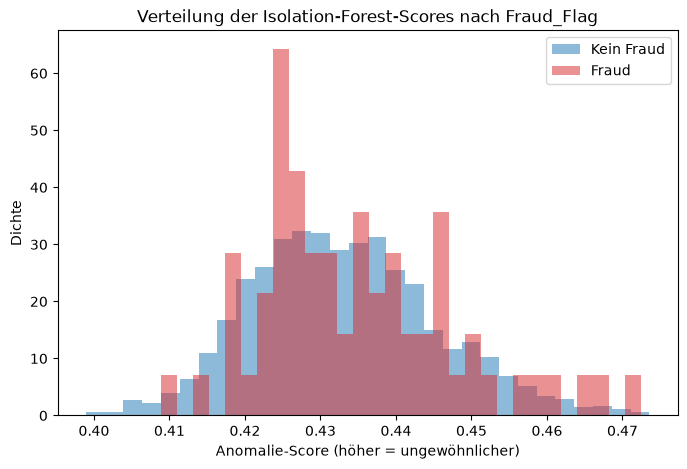

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for flag, label, farbe in [(0, "Kein Fraud", "tab:blue"), (1, "Fraud", "tab:red")]:
    werte = luxury_datensatz.loc[luxury_datensatz["Fraud_Flag"] == flag, "Anomalie_Score"]
    ax.hist(werte, bins=30, density=True, alpha=0.5, label=label, color=farbe)

ax.set_xlabel("Anomalie-Score (höher = ungewöhnlicher)")
ax.set_ylabel("Dichte")
ax.set_title("Verteilung der Isolation-Forest-Scores nach Fraud_Flag")
ax.legend()
plt.show()


Der ROC-AUC von ~0,53 liegt praktisch auf Zufallsniveau (0,5 = Zufall).

In [63]:
vergleich_mittelwerte = luxury_datensatz.groupby("Fraud_Flag")[numerische_merkmale].mean()
print(vergleich_mittelwerte)
print()
print(f"Eindeutige Customer_ID: {luxury_datensatz['Customer_ID'].nunique()} von {len(luxury_datensatz)} Zeilen")
print(f"Eindeutige IP_Address: {luxury_datensatz['IP_Address'].nunique()} von {len(luxury_datensatz)} Zeilen")

            Customer_Age  Purchase_Amount  Footfall_Count  Transaction_Stunde
Fraud_Flag                                                                   
0              41.665479       174.865104      271.966134           12.027576
1              42.269841       166.752273      287.984848           11.424242

Eindeutige Customer_ID: 2133 von 2133 Zeilen
Eindeutige IP_Address: 2133 von 2133 Zeilen


### Zusammenfassung & Handlungsempfehlungen

**Ergebnis:** Der `IsolationForest` markiert 66 Transaktionen als Anomalie, trifft davon aber nur 4 der 66 tatsächlichen Fraud-Fälle — der ROC-AUC von ~0,53 liegt auf Zufallsniveau.

**Handlungsempfehlungen:**

1. **Merkmale reichen nicht aus, um Fraud zu erklären.** Mit den aktuellen Transaktionsmerkmalen ist Betrugserkennung per Isolation Forest nicht sinnvoll möglich. Bevor mehr Modellierungsaufwand investiert wird, sollte zuerst geprüft werden, ob überhaupt zusätzliche, aussagekräftigere Merkmale verfügbar sind.
2. **Verhaltensbasierte Merkmale erheben.** Da im Datensatz jede `Customer_ID` und `IP_Address` nur genau einmal vorkommt, lassen sich klassische Fraud-Signale wie Transaktionsfrequenz pro Kunde/IP, Geräte- oder Ortswechsel innerhalb kurzer Zeit oder Abweichung vom individuellen Kaufmuster nicht berechnen. Eine Datenerhebung mit mehreren Transaktionen pro Kunde wäre dafür Voraussetzung.
3. **Isolation Forest trotzdem als Qualitäts-Werkzeug nutzen.** Auch ohne Deckung mit `Fraud_Flag` markieren die gefundenen Anomalien strukturell ungewöhnliche Kombinationen der vorhandenen Merkmale (z. B. untypische Kombination aus Kategorie, Zahlungsart und Uhrzeit) und eignen sich als Ausgangspunkt für manuelle Stichprobenprüfung im Rahmen der Datenqualitätssicherung — unabhängig vom eigentlichen Fraud-Use-Case.
4. **`contamination` ist in Produktion nicht aus der Ground Truth ableitbar.** Hier konnte der Parameter anhand des bekannten `Fraud_Flag` gesetzt werden; ohne Label müsste er geschätzt oder anhand von Kapazität für manuelle Prüfungen festgelegt werden.
